# Esconder un mensaje en imagen usando los Bitwise Operators
## Esconder Mensajes Secretos en Fotos

**Estudiante:** Andy Ignacio Jesus Villarroel Gonzalez
**Fecha:** 15/03/2026

## Introducción

La idea es simple: esconder un mensaje de texto dentro de una foto sin que se note a simple vista. 

Cada píxel tiene 3 colores (Rojo, Verde, Azul), y cada color es un número de 0-255. Los números se guardan como bits, y los **bits menos significativos** (los últimos) casi no afectan el color visualmente.

Entonces, en lugar de cambiar todo el color, solo modificamos los últimos bits para guardar nuestro mensaje.

### Los 3 modos:
- **Partes=3:** 3 bits en Rojo, 3 en Verde, 2 en Azul = 1 letra por píxel
- **Partes=6:** 6 bits distribuidos en 2 píxeles = más robusto
- **Partes=8:** 8 bits distribuidos en ~3 píxeles = súper robusto

Antes de partir te explico las librerias que use.

re (regex)
Esta viene incluida en Python, no hay que instalar nada. La uso únicamente para buscar el patrón &&mensaje&& dentro del texto recuperado. Podría haberlo hecho con un loop manual comparando caracter a caracter, pero regex lo hace en una línea y es más claro.

itertools.cycleTambién viene con Python. La uso para repetir el mensaje en toda la foto — en vez de escribirlo solo en los primeros pixels, el mensaje da vueltas de principio a fin por toda la imagen. Eso es lo que permite recuperarlo aunque la foto esté recortada, porque el patrón &&...&& aparece múltiples veces distribuido en todos los pixels.

In [ ]:
import re
from PIL import Image
from itertools import cycle
from IPython.display import display

class Imagen:
    ## clase principal para todo lo de la foto, asi no quedan variables
    ## sueltas por todos lados y queda mas ordenado

    def __init__(self, nombre_archivo):
        ## convierto a RGB porque a veces las fotos vienen en RGBA
        ## (con transparencia) y despues eso rompe todo
        self.img = Image.open(nombre_archivo).convert('RGB')
        print(f"✓ Foto cargada: {self.img.size}")
        
    def show(self):
        ## muestra la imagen en el notebook, nada fancy
        display(self.img)
        
    def guardar(self, nombre_salida):
        ## guarda la foto, util para despues comparar con el original
        self.img.save(nombre_salida)
        print(f"✓ Guardado como: {nombre_salida}")

    def __ne__(self, other):
        ## son distintas si algun pixel difiere, uso XOR canal a canal
        ## si da 0 son iguales, cualquier otra cosa significa que cambio algo
        return not self.__eq__(other)

    def encode(self, msg, partes):
        ## aca va la magia, escondo el mensaje en los bits menos significativos
        ## de cada canal RGB, la idea es que visualmente no se note nada
        print(f"\nEscondiendo: '{msg}' (partes={partes})")
        
        ## envuelvo el mensaje con && para poder encontrarlo despues
        ## el cycle repite el mensaje en toda la foto, no solo al inicio
        ## eso es lo que hace que funcione como marca de agua
        msg_completo = f"&&{msg}&&"
        bytes_msg = [ord(c) for c in msg_completo]
        iterador_msg = cycle(bytes_msg)
        
        ## dependiendo de las partes, distribuyo los bits distinto:
        ## partes=3: 3+3+2 bits en 1 pixel (1 letra por pixel, mas compacto)
        ## partes=6: distribuido en 2 pixeles (balance entre espacio y robustez)
        ## partes=8: 1 bit por canal, ~3 pixeles por letra (mas robusto, menos compacto)
        def generador_bits():
            for letra in iterador_msg:
                if partes == 3:
                    yield (letra >> 5) & 0b111, 0b11111000  ## bits 7-5
                    yield (letra >> 2) & 0b111, 0b11111000  ## bits 4-2
                    yield letra & 0b011,        0b11111100  ## bits 1-0
                    
                elif partes == 6:
                    yield (letra >> 6) & 0b011, 0b11111100
                    yield (letra >> 4) & 0b011, 0b11111100
                    yield (letra >> 3) & 0b001, 0b11111110
                    yield (letra >> 2) & 0b001, 0b11111110
                    yield (letra >> 1) & 0b001, 0b11111110
                    yield letra & 0b001,        0b11111110
                    
                elif partes == 8:
                    yield (letra >> 7) & 0b1, 0b11111110
                    yield (letra >> 6) & 0b1, 0b11111110
                    yield (letra >> 5) & 0b1, 0b11111110
                    yield (letra >> 4) & 0b1, 0b11111110
                    yield (letra >> 3) & 0b1, 0b11111110
                    yield (letra >> 2) & 0b1, 0b11111110
                    yield (letra >> 1) & 0b1, 0b11111110
                    yield letra & 0b1,        0b11111110

        iterador_bits = generador_bits()
        ancho, alto = self.img.size
        
        for y in range(alto):
            for x in range(ancho):
                pixel = list(self.img.getpixel((x, y)))
                for i in range(3):
                    parte, mascara = next(iterador_bits)
                    ## la mascara limpia los bits donde voy a escribir (AND)
                    ## y despues meto ahi los bits del mensaje (OR)
                    pixel[i] = (pixel[i] & mascara) | parte
                self.img.putpixel((x, y), tuple(pixel))
        
        print("Listo")

    def _decode_parts(self, partes):
        ## intenta recuperar el mensaje asumiendo un modo especifico
        ## si no encuentra el patron &&..&& retorna None
        ## y decode() prueba con el siguiente modo
        caracteres = []
        ancho, alto = self.img.size
        
        ## recorro los canales en el mismo orden que al encodear, importante esto
        def generador_canales():
            for y in range(alto):
                for x in range(ancho):
                    pixel = self.img.getpixel((x, y))
                    yield pixel[0]
                    yield pixel[1]
                    yield pixel[2]
                        
        canales = generador_canales()
        
        try:
            while True:
                if partes == 3:
                    ## proceso inverso del encode, extraigo con AND y reensamblo con shifts y OR
                    p1 = next(canales) & 0b111
                    p2 = next(canales) & 0b111
                    p3 = next(canales) & 0b011
                    letra_byte = (p1 << 5) | (p2 << 2) | p3
                    
                elif partes == 6:
                    p1 = next(canales) & 0b011
                    p2 = next(canales) & 0b011
                    p3 = next(canales) & 0b001
                    p4 = next(canales) & 0b001
                    p5 = next(canales) & 0b001
                    p6 = next(canales) & 0b001
                    letra_byte = (p1 << 6) | (p2 << 4) | (p3 << 3) | (p4 << 2) | (p5 << 1) | p6
                    
                elif partes == 8:
                    p1 = next(canales) & 0b1
                    p2 = next(canales) & 0b1
                    p3 = next(canales) & 0b1
                    p4 = next(canales) & 0b1
                    p5 = next(canales) & 0b1
                    p6 = next(canales) & 0b1
                    p7 = next(canales) & 0b1
                    p8 = next(canales) & 0b1
                    letra_byte = (p1 << 7) | (p2 << 6) | (p3 << 5) | (p4 << 4) | (p5 << 3) | (p6 << 2) | (p7 << 1) | p8
                
                caracteres.append(chr(letra_byte))
                
        except StopIteration:
            pass 
            
        texto_completo = "".join(caracteres)
        ## busco el patron con regex, puede aparecer varias veces por el cycle
        ## me quedo con la coincidencia mas corta para evitar basura
        coincidencias = re.findall(r'&&(.+?)&&', texto_completo)
        
        if coincidencias:
            return min(coincidencias, key=len)
        return None
    
    def decode(self):
        ## prueba los 3 modos automaticamente, el primero que encuentre && gana
        ## asi no hay que saber con que modo se encodeo, se autodetecta
        print("\nBuscando mensaje...")
        
        for partes in [8, 6, 3]:
            resultado = self._decode_parts(partes)
            if resultado is not None:
                print(f"Encontrado con partes={partes}")
                return resultado
        
        print("No se encontro mensaje")
        return None

✓ Foto cargada: (1536, 2048)

Escondiendo: 'hola com estas bato' (partes=6)
Listo
✓ Guardado como: foto_con_mensaje.png
✓ Foto cargada: (1536, 2048)


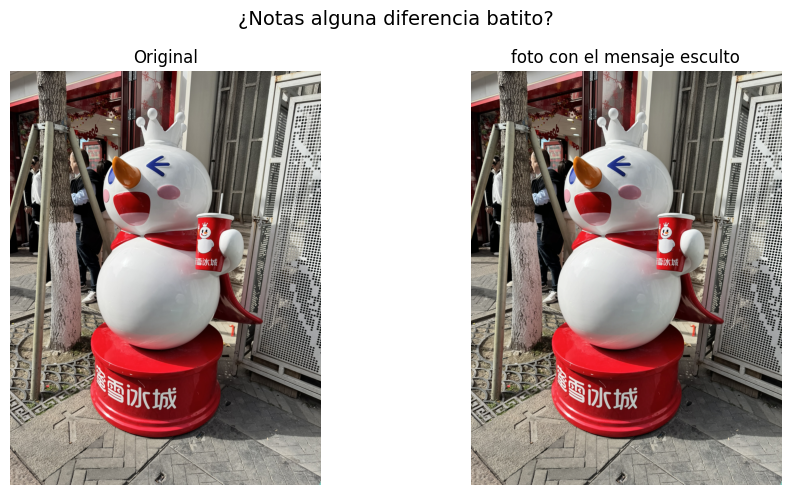

In [39]:
import matplotlib.pyplot as plt ##para mostrar las imagenes y asi compararlas

## Creamos la parte del codigo para probar la clase
foto = Imagen("IMG_2259.png")
cantidad_partes = input("¿En cuántas partes quieres dividir cada letra? (3, 6 u 8): ")
while cantidad_partes not in ['3', '6', '8']:
    cantidad_partes = input("Por favor ingresa 3, 6 u 8: ")
mensaje = input("Escribe el mensaje que quieres esconder: ")
foto.encode(mensaje, int(cantidad_partes))

##mostramos las imagen lado a lado para que el usario pueda comparar
### aca guardamos las imagenes para luego mostrarlas con el matplotlib
foto.guardar("foto_con_mensaje.png")
foto_original = Imagen("IMG_2259.png")

## las mostramos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(foto_original.img)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(foto.img)
axes[1].set_title("foto con el mensaje esculto")
axes[1].axis('off')

plt.suptitle("¿Notas alguna diferencia batito?", fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
##ahora decodeamos la imagen para verificar que funcione
mensaje_recuperado = foto.decode()
print(f"Mensaje recuperado: '{mensaje_recuperado}'")

## no sabia si dejarte una conclusion pero te dejo una por si acaso.


Buscando mensaje...
Encontrado con partes=6
Mensaje recuperado: 'hola me duga el minecraft'


## Conclusiones

Al final logré que los tres modos funcionen bien y que 
el mensaje sobreviva incluso si recortas la foto, que era lo más complicado. Lo más 
interesante fue darme cuenta de que cambiar solo los últimos bits realmente no se 
nota visualmente nada, las fotos quedan prácticamente idénticas.
También me gustó lo de la autodetección, que el 
decode pruebe los modos solo sin que el usuario tenga que saber con cuál se encodeó. 